In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


spark-3.1.1-bin-hadoop3.2.tgz

In [ ]:
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
# !wget -q http://archive.apache.org/dist/spark/spark-3.1.1/spark-3.1.1-bin-hadoop3.2.tgz
!cp /content/drive/MyDrive/MMDS-data/spark-3.1.1-bin-hadoop3.2.tgz .
!tar xf spark-3.1.1-bin-hadoop3.2.tgz
!pip install -q findspark

spark-3.1.1-bin-hadoop3.2.gz

In [ ]:
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
!cp /content/drive/MyDrive/MMDS-data/spark-3.1.1-bin-hadoop3.2.gz .
!tar xf spark-3.1.1-bin-hadoop3.2.gz
!pip install -q findspark

In [ ]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.1.1-bin-hadoop3.2"
import findspark
findspark.init()

In [ ]:
from pyspark.sql import SparkSession
spark = SparkSession.builder \
        .appName("midterm") \
        .getOrCreate()

sc = spark.sparkContext
baskets = "/content/drive/MyDrive/MMDS-data/baskets.csv"

##**Task 01:**

**RDDs**

In [ ]:
import os

def read_file(file_path):
    if not os.path.exists(file_path):
        return None
    rdd = sc.textFile(file_path)
    header = rdd.first()
    rdd = rdd.filter(lambda row: row != header)
    return rdd.map(lambda line: line.split(","))

In [ ]:
import matplotlib.pyplot as plt

def bar_chart_visualize(items, frequencies, title, xlabel, ylabel, folder, file_name):
    plt.figure(figsize=(16, 8))
    plt.bar(items, frequencies, color='skyblue')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks(rotation=90)

    save_dir = "/content/" + folder
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    plt.savefig(os.path.join(save_dir, f"{file_name}.jpg"), format='jpg')
    plt.show()

def barh_chart_visualize(items, frequencies, title, xlabel, ylabel, folder, file_name):
    plt.figure(figsize=(14, 16))
    plt.barh(items, frequencies, color='skyblue')
    plt.xlabel(xlabel, fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.title(title, fontsize=16)
    plt.gca().invert_yaxis()

    save_dir = "/content/" + folder
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    plt.savefig(os.path.join(save_dir, f"{file_name}.jpg"), format='jpg')
    plt.show()

def chart_visualize(items, frequencies, title, xlabel, ylabel, folder, file_name):
    plt.plot(items, frequencies, marker='o')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks(rotation=90)
    plt.grid(True)
    plt.tight_layout()

    save_dir = "/content/" + folder
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    plt.savefig(os.path.join(save_dir, f"{file_name}.jpg"), format='jpg')
    plt.show()

In [ ]:
from pyspark.sql import DataFrame
from pyspark.rdd import RDD

def save(data, file_name):
    save_dir = f"/content/{file_name}"

    if os.path.exists(save_dir):
        os.system(f"rm -rf {save_dir}")

    if isinstance(data, RDD):  # RDD
        data.coalesce(1).saveAsTextFile(save_dir)

    elif isinstance(data, DataFrame):  # DataFrame
        data.coalesce(1).write.csv(save_dir, header=True)

    else:
        print("Unsupported data type. Please provide an RDD or DataFrame.")

In [ ]:
# @title Function f1
def f1_rdd(file_path, save_path="f1_rdd", chart_path="f1"):
    rdd = read_file(file_path)
    top_products = rdd.map(lambda line: (line[2], 1)) \
                      .reduceByKey(lambda a, b: a + b) \
                      .takeOrdered(100, key=lambda x: -x[1])

    for product, count in top_products:
        print(f"{product}: {count} purchases")

    rdd_top_products = sc.parallelize(top_products).map(lambda result: f"{result[0]},{result[1]}")
    save(rdd_top_products, save_path)

    products, purchase_counts = zip(*top_products)
    barh_chart_visualize(
        products,
        purchase_counts,
        "Top 100 most purchased items",
        "Number of times each item has been purchased",
        "List of distinct items",
        save_path,
        chart_path
    )

In [ ]:
# @title Function f2
def f2_rdd(file_path, save_path="f2_rdd", chart_path="f2"):
  rdd = read_file(file_path)
  count_sorted_baskets = rdd.map(lambda line: ((line[0], line[1]), line[2])) \
                            .groupByKey() \
                            .map(lambda x: (x[0][0], 1)) \
                            .reduceByKey(lambda a, b: a + b) \
                            .sortBy(lambda item: item[1], ascending = False) \
                            .take(100)

  for member, count in count_sorted_baskets:
    print(f"Member_number {member}: {count} baskets")

  rdd_top_customers = sc.parallelize(count_sorted_baskets).map(lambda result: f"{result[0]},{result[1]}")
  save(rdd_top_customers, save_path)

  members, baskets_count = zip(*count_sorted_baskets)
  bar_chart_visualize(
        members,
        baskets_count,
        "Top 100 customers with the most shopping baskets",
        "Member_number",
        "Number of shopping baskets",
        save_path,
        chart_path
    )

In [ ]:
# @title Function f3
def f3_rdd(file_path, save_path="f3_rdd", chart_path="f3"):
  rdd = read_file(file_path)
  results = rdd.map(lambda line: ((int(line[4]), line[2]), 1)) \
               .reduceByKey(lambda a, b: a + b) \
               .sortByKey()

  for result in results.toLocalIterator():
      (month, item), count = result
      print(f"Month: {month}, Item: {item}, Count: {count}")

  csv_rdd = results.map(lambda result: f"{result[0][0]},{result[0][1]},{result[1]}")
  save(csv_rdd, save_path)

  monthly_counts = rdd.map(lambda line: (int(line[4]), 1)) \
                      .reduceByKey(lambda a, b: a + b) \
                      .sortByKey()

  monthly_counts_list = monthly_counts.map(lambda record: (record[0], record[1])).collect()

  months = [record[0] for record in monthly_counts_list]
  counts = [record[1] for record in monthly_counts_list]

  chart_visualize(
        months,
        counts,
        "Number of Purchases Over Time",
        "Month",
        "Number of Purchases",
        save_path,
        chart_path
    )

In [ ]:
# @title Function f4
def f4_rdd(file_path, save_path="f4_rdd", chart_path="f4"):
  rdd = read_file(file_path)
  purchasing_per_month = rdd.map(lambda fields: ((fields[0], fields[1]), (fields[3], fields[4]))) \
                            .distinct() \
                            .map(lambda x: ((int(x[1][0]), int(x[1][1])), 1)) \
                            .reduceByKey(lambda a, b: a + b) \
                            .sortByKey()

  save(purchasing_per_month, save_path)
  results = purchasing_per_month.collect()

  for (year, month), count in results:
    print(f"Year-Month: {year}-{month} -- {count}")

  months = [f"{row[0][0]}-{row[0][1]}" for row in results]
  counts = [row[1] for row in results]

  chart_visualize(
      months,
      counts,
      "Number of Purchases Over Time",
      "Year-Month",
      "Number of Purchases",
      save_path,
      chart_path
  )

Top 100 most purchased items:

whole milk: 2502 purchases
other vegetables: 1898 purchases
rolls/buns: 1716 purchases
soda: 1514 purchases
yogurt: 1334 purchases
root vegetables: 1071 purchases
tropical fruit: 1032 purchases
bottled water: 933 purchases
sausage: 924 purchases
citrus fruit: 812 purchases
pastry: 785 purchases
pip fruit: 744 purchases
shopping bags: 731 purchases
canned beer: 717 purchases
bottled beer: 687 purchases
whipped/sour cream: 662 purchases
newspapers: 596 purchases
frankfurter: 580 purchases
brown bread: 571 purchases
domestic eggs: 566 purchases
pork: 566 purchases
butter: 534 purchases
fruit/vegetable juice: 518 purchases
beef: 516 purchases
curd: 514 purchases
margarine: 491 purchases
coffee: 476 purchases
frozen vegetables: 425 purchases
chicken: 422 purchases
white bread: 362 purchases
cream cheese : 358 purchases
chocolate: 357 purchases
dessert: 356 purchases
napkins: 335 purchases
hamburger meat: 327 purchases
berries: 327 purchases
UHT-milk: 323 purch

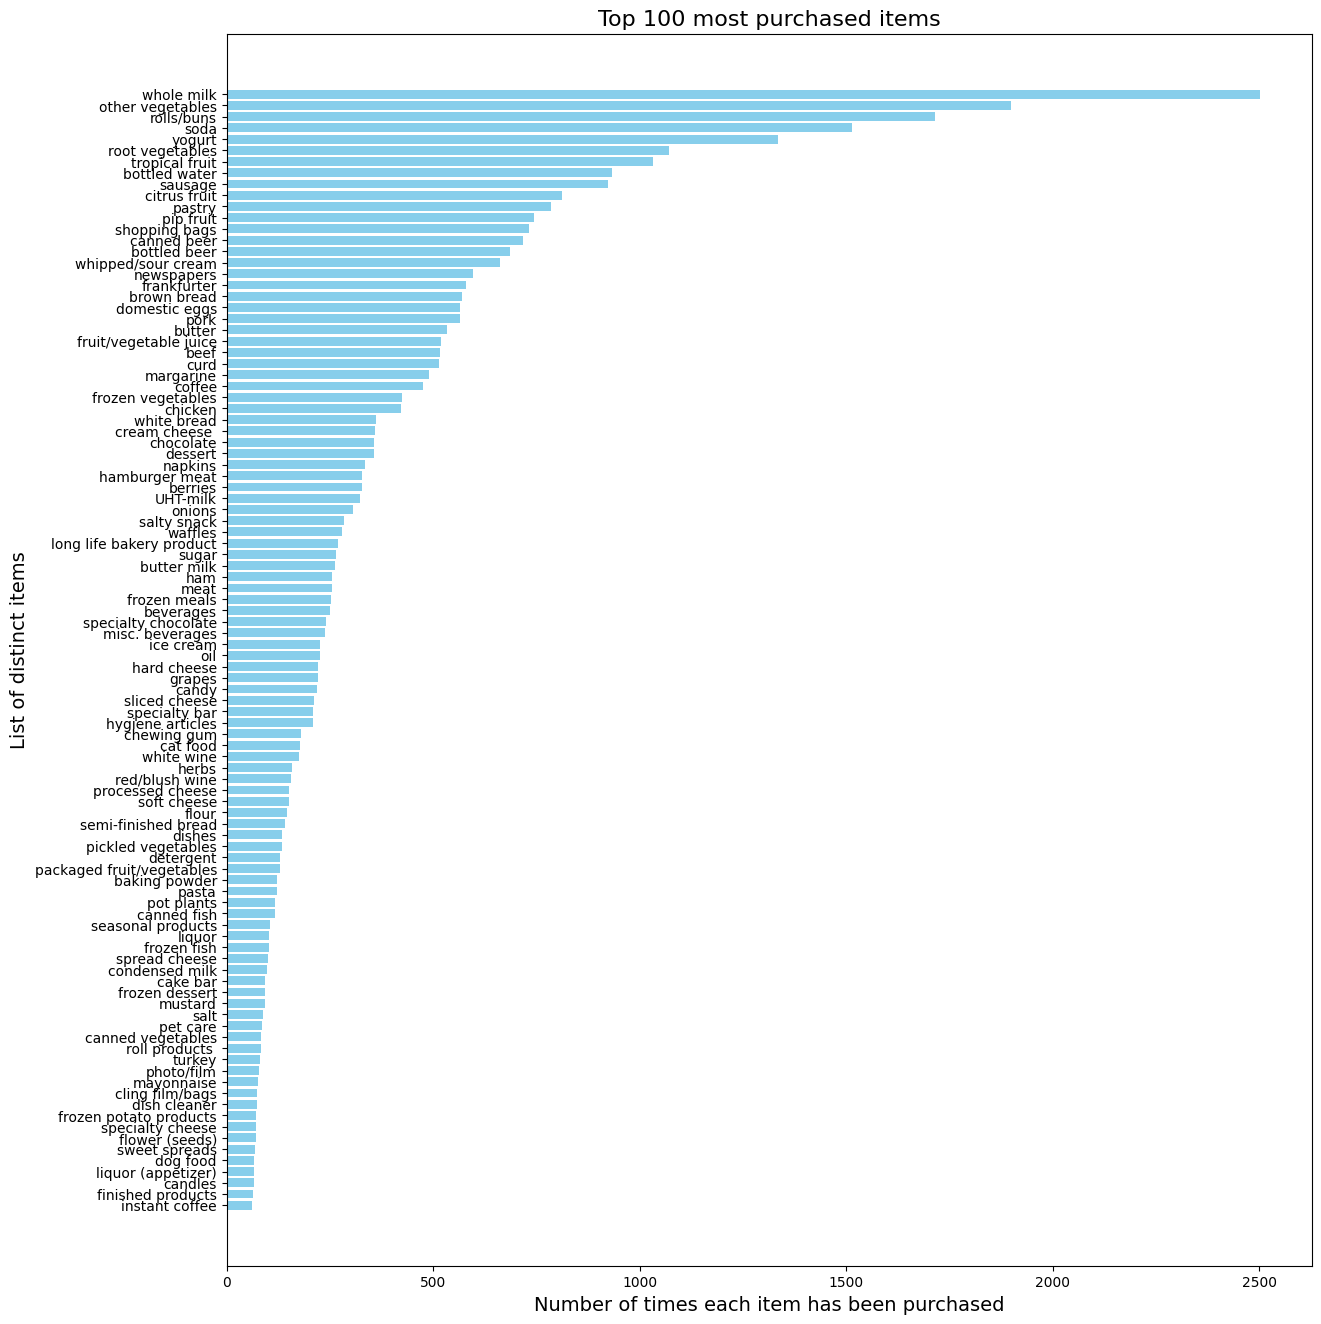

In [ ]:
print("Top 100 most purchased items:\n")
result_f1 = f1_rdd(baskets)

Top 100 customers with the most shopping baskets:

Member_number 2271: 11 baskets
Member_number 1379: 11 baskets
Member_number 4338: 11 baskets
Member_number 3737: 11 baskets
Member_number 2193: 11 baskets
Member_number 1574: 10 baskets
Member_number 4217: 10 baskets
Member_number 2524: 10 baskets
Member_number 2394: 10 baskets
Member_number 4864: 10 baskets
Member_number 3180: 10 baskets
Member_number 3872: 10 baskets
Member_number 1793: 10 baskets
Member_number 3915: 10 baskets
Member_number 3120: 10 baskets
Member_number 4376: 10 baskets
Member_number 1052: 10 baskets
Member_number 1908: 10 baskets
Member_number 3289: 10 baskets
Member_number 3082: 10 baskets
Member_number 3248: 10 baskets
Member_number 1410: 10 baskets
Member_number 3484: 10 baskets
Member_number 2625: 10 baskets
Member_number 1275: 10 baskets
Member_number 3593: 10 baskets
Member_number 2851: 9 baskets
Member_number 3221: 9 baskets
Member_number 4303: 9 baskets
Member_number 1566: 9 baskets
Member_number 3830: 9 b

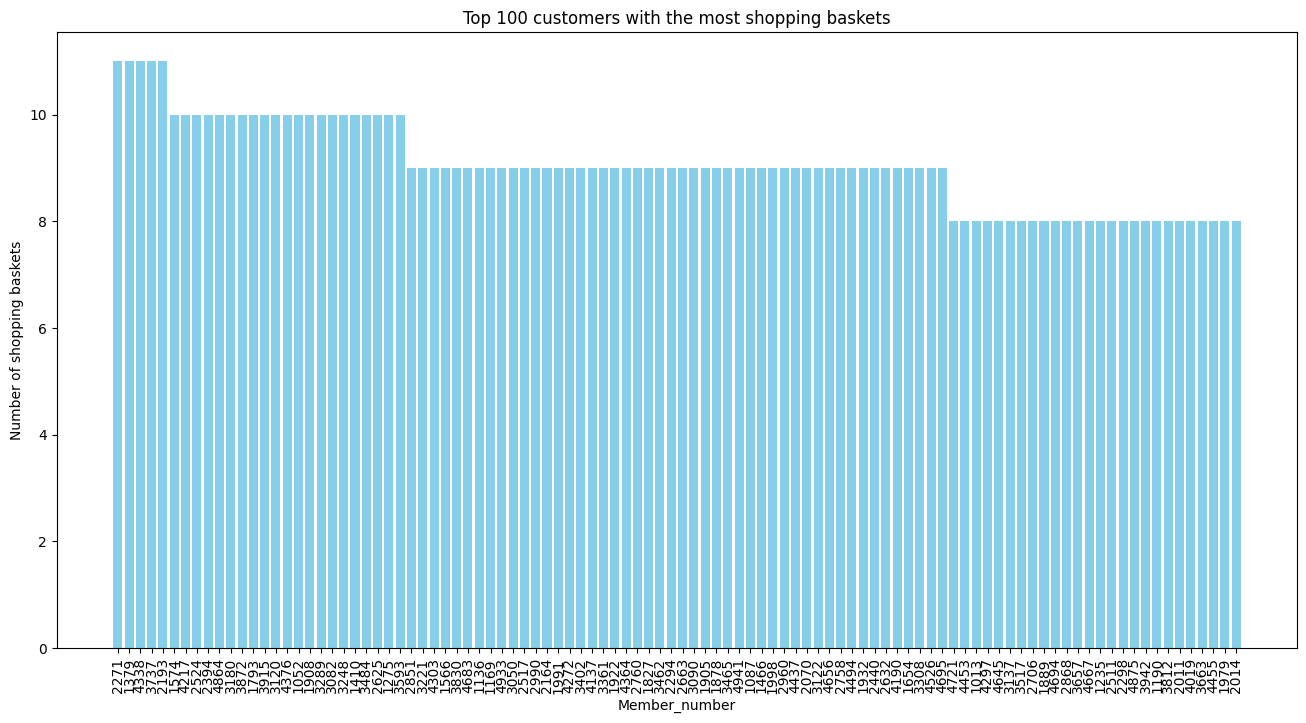

In [ ]:
print("Top 100 customers with the most shopping baskets:\n")
result_f2 = f2_rdd(baskets)

The number of times items have been purchased (in shopping baskets) by month:

Month: 1, Item: Instant food products, Count: 5
Month: 1, Item: UHT-milk, Count: 20
Month: 1, Item: abrasive cleaner, Count: 1
Month: 1, Item: artif. sweetener, Count: 3
Month: 1, Item: baking powder, Count: 7
Month: 1, Item: beef, Count: 45
Month: 1, Item: berries, Count: 26
Month: 1, Item: beverages, Count: 15
Month: 1, Item: bottled beer, Count: 64
Month: 1, Item: bottled water, Count: 72
Month: 1, Item: brandy, Count: 1
Month: 1, Item: brown bread, Count: 64
Month: 1, Item: butter, Count: 43
Month: 1, Item: butter milk, Count: 24
Month: 1, Item: cake bar, Count: 2
Month: 1, Item: candles, Count: 7
Month: 1, Item: candy, Count: 16
Month: 1, Item: canned beer, Count: 50
Month: 1, Item: canned fish, Count: 13
Month: 1, Item: canned fruit, Count: 2
Month: 1, Item: canned vegetables, Count: 6
Month: 1, Item: cat food, Count: 21
Month: 1, Item: cereals, Count: 4
Month: 1, Item: chewing gum, Count: 17
Month: 1,

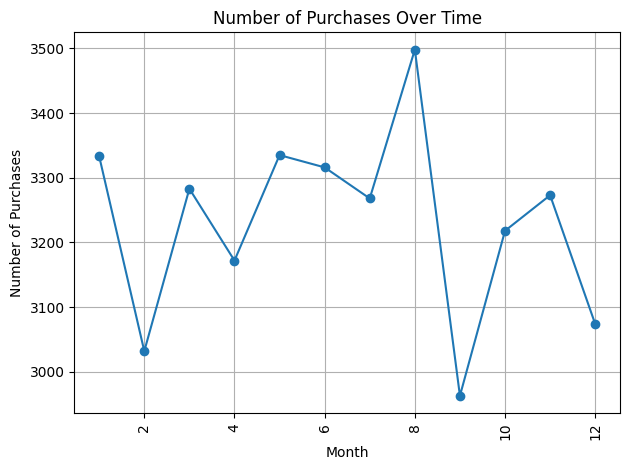

In [ ]:
print("The number of times items have been purchased (in shopping baskets) by month:\n")
result_f3 = f3_rdd(baskets)

The number of purchases (shopping baskets) made by customers each month:

Year-Month: 2014-1 -- 659
Year-Month: 2014-2 -- 671
Year-Month: 2014-3 -- 650
Year-Month: 2014-4 -- 657
Year-Month: 2014-5 -- 702
Year-Month: 2014-6 -- 653
Year-Month: 2014-7 -- 700
Year-Month: 2014-8 -- 673
Year-Month: 2014-9 -- 596
Year-Month: 2014-10 -- 694
Year-Month: 2014-11 -- 661
Year-Month: 2014-12 -- 665
Year-Month: 2015-1 -- 632
Year-Month: 2015-2 -- 522
Year-Month: 2015-3 -- 584
Year-Month: 2015-4 -- 567
Year-Month: 2015-5 -- 585
Year-Month: 2015-6 -- 602
Year-Month: 2015-7 -- 572
Year-Month: 2015-8 -- 660
Year-Month: 2015-9 -- 548
Year-Month: 2015-10 -- 566
Year-Month: 2015-11 -- 611
Year-Month: 2015-12 -- 533


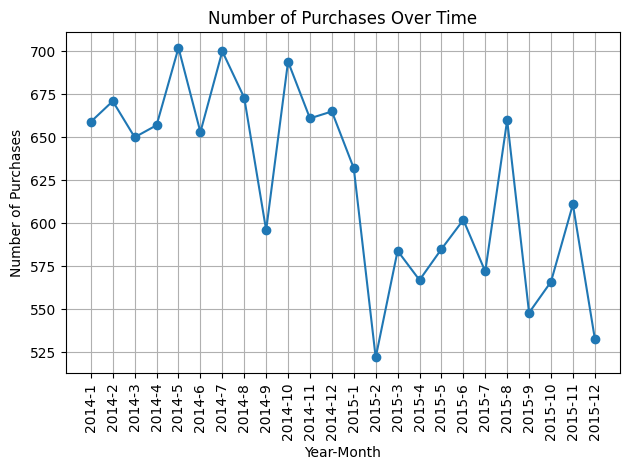

In [ ]:
print("The number of purchases (shopping baskets) made by customers each month:\n")
result_f4 = f4_rdd(baskets)

**DataFrames**

In [ ]:
from pyspark.sql.functions import col
from pyspark.sql import functions as F

df = spark.read.csv(baskets, header=True, inferSchema=True)
df.printSchema()

root
 |-- Member_number: integer (nullable = true)
 |-- Date: string (nullable = true)
 |-- itemDescription: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- day: integer (nullable = true)
 |-- day_of_week: integer (nullable = true)



In [ ]:
# @title Function f1
def f1_df(df, save_path="f1_df", chart_path="f1"):
  item_counts_df = df.groupBy("itemDescription").agg(F.count("itemDescription").alias("purchase_count"))
  sorted_items_df = item_counts_df.orderBy(F.col("purchase_count").desc())
  top_100_items_df = sorted_items_df.limit(100)
  top_100_items_df.show(100)

  save(top_100_items_df, save_path)
  top_100_items = top_100_items_df.collect()

  items = [row["itemDescription"] for row in top_100_items]
  purchase_counts = [row["purchase_count"] for row in top_100_items]

  barh_chart_visualize(
      items,
      purchase_counts,
      "Top 100 most purchased items",
      "Number of times each item has been purchased",
      "List of distinct items",
      save_path,
      chart_path
  )

In [ ]:
# @title Function f2
import pandas as pd

def f2_df(df, save_path="f2_df", chart_path="f2"):
  df_count_sorted_baskets = df.groupBy('Member_number', 'Date') \
                              .agg(F.countDistinct('itemDescription').alias('items')) \
                              .groupBy('Member_number') \
                              .agg(F.count('*').alias('total_baskets')) \
                              .orderBy(F.col('total_baskets').desc()) \
                              .limit(100)

  save(df_count_sorted_baskets, save_path)
  df_count_sorted_baskets.show()

  df_baskets = df_count_sorted_baskets.withColumn("Member_number", F.col("Member_number") \
                                      .cast("string"))

  df_baskets_pd = df_baskets.toPandas()
  bar_chart_visualize(
      df_baskets_pd['Member_number'],
      df_baskets_pd['total_baskets'],
      "Top 100 customers with the most shopping baskets",
      "Member_number",
      "Number of shopping baskets",
      save_path,
      chart_path
  )

In [ ]:
# @title Function f3
def f3_df(df, save_path="f3_df", chart_path="f3"):
  count_item_with_month = df.groupBy("month", "itemDescription") \
                            .count() \
                            .orderBy("month")

  save(count_item_with_month, save_path)
  monthly_counts = df.groupBy("month") \
                     .count() \
                     .orderBy("month")

  monthly_counts.show()
  months = monthly_counts.select("month").rdd.flatMap(lambda x: x).collect()
  counts = monthly_counts.select("count").rdd.flatMap(lambda x: x).collect()

  chart_visualize(
      months,
      counts,
      "Number of Purchases Over Time",
      "Month",
      "Number of Purchases",
      save_path,
      chart_path
  )

In [ ]:
# @title Function f4
import pandas as pd
from pyspark.sql.functions import col, countDistinct, to_date, year, month, count, collect_set, first

def f4_df(df, save_path="f4_df", chart_path="f4"):
  purchasing_per_month_df = df.groupBy('Member_number', 'Date') \
                              .agg(
                                  collect_set('itemDescription').alias('Items'),
                                  first('year').alias('year'),
                                  first('month').alias('month'),
                                  first('day').alias('day')
                              ) \
                              .orderBy('Date')

  monthly_purchases_df = purchasing_per_month_df.groupBy('year', 'month') \
                                                .count() \
                                                .orderBy('year', 'month')

  monthly_purchases_df.show(30, truncate=False)
  save(monthly_purchases_df, save_path)

  pandas_df = monthly_purchases_df.toPandas()
  pandas_df['Year-Month'] = pandas_df['year'].astype(str) + '-' + pandas_df['month'].astype(str).str.zfill(2)
  pandas_df = pandas_df.sort_values('Year-Month')

  year_month = pandas_df['Year-Month']
  count = pandas_df['count']

  chart_visualize(
      year_month,
      count,
      "Number of Purchases Over Time",
      "Year-Month",
      "Number of Purchases",
      save_path,
      chart_path
  )

Top 100 most purchased items:

+--------------------+--------------+
|     itemDescription|purchase_count|
+--------------------+--------------+
|          whole milk|          2502|
|    other vegetables|          1898|
|          rolls/buns|          1716|
|                soda|          1514|
|              yogurt|          1334|
|     root vegetables|          1071|
|      tropical fruit|          1032|
|       bottled water|           933|
|             sausage|           924|
|        citrus fruit|           812|
|              pastry|           785|
|           pip fruit|           744|
|       shopping bags|           731|
|         canned beer|           717|
|        bottled beer|           687|
|  whipped/sour cream|           662|
|          newspapers|           596|
|         frankfurter|           580|
|         brown bread|           571|
|       domestic eggs|           566|
|                pork|           566|
|              butter|           534|
|fruit/vegetable j.

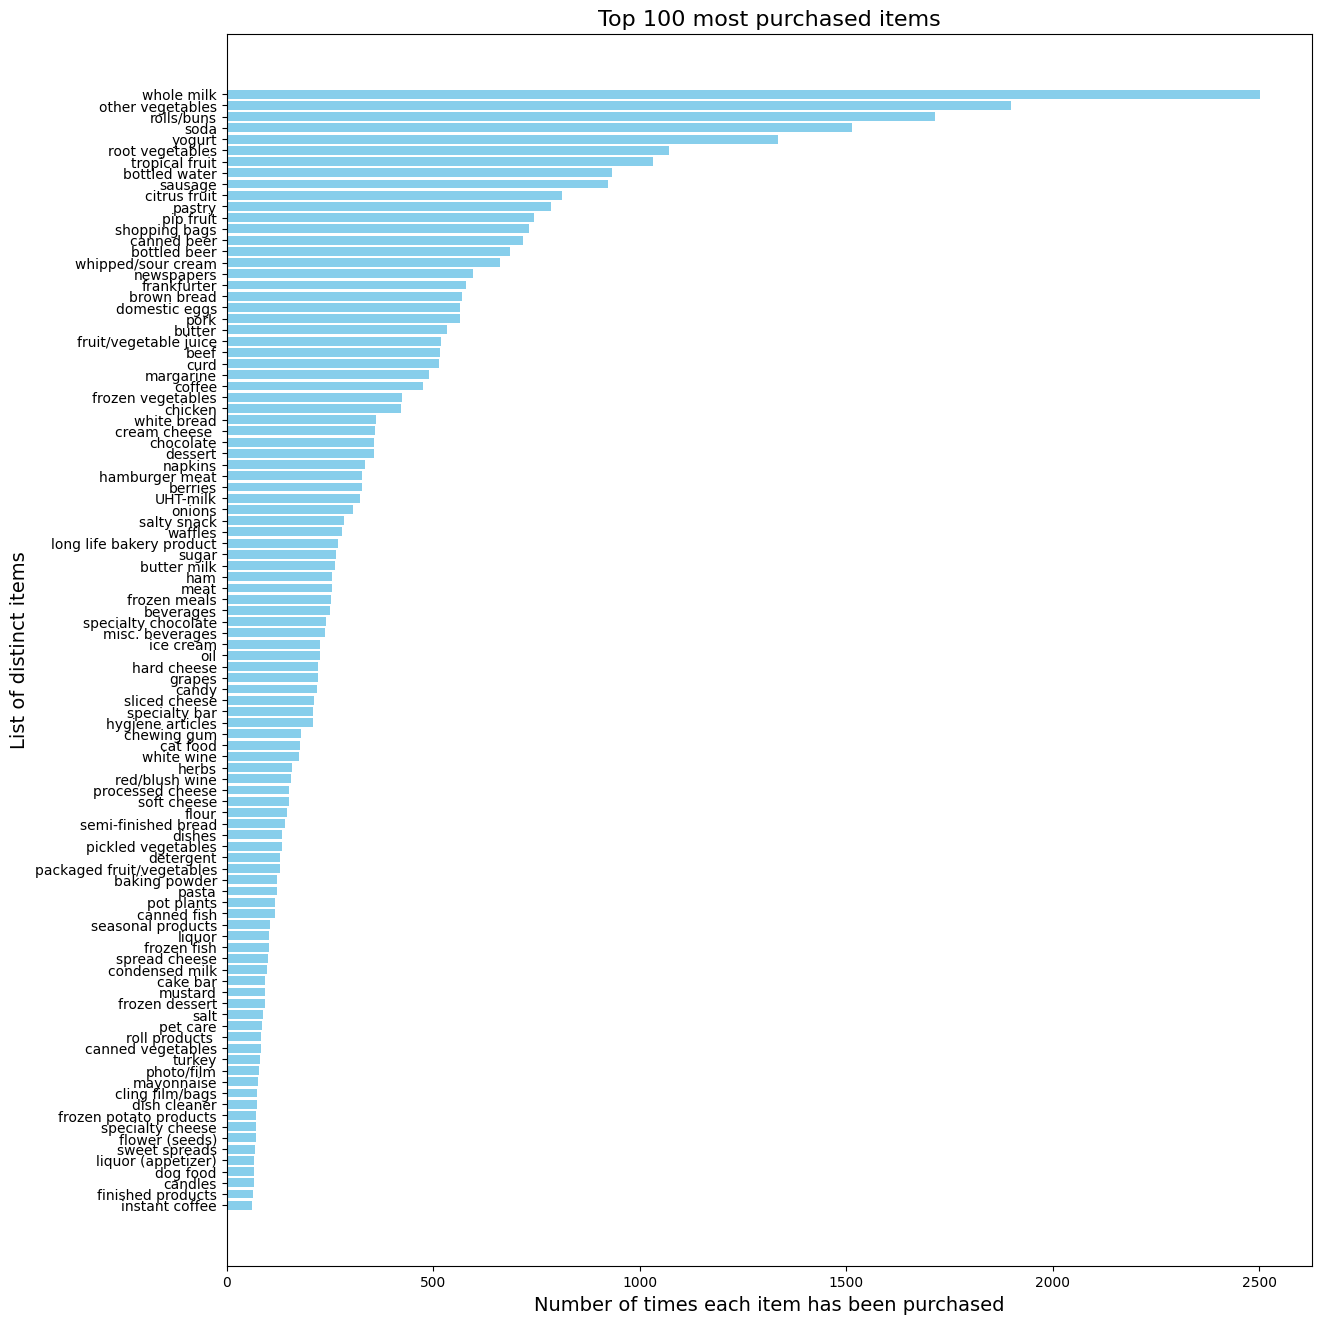

In [ ]:
print("Top 100 most purchased items:\n")
result_f1_df = f1_df(df)

Top 100 customers with the most shopping baskets:

+-------------+-------------+
|Member_number|total_baskets|
+-------------+-------------+
|         4338|           11|
|         2193|           11|
|         2271|           11|
|         1379|           11|
|         3737|           11|
|         2625|           10|
|         1574|           10|
|         1908|           10|
|         3180|           10|
|         4376|           10|
|         3593|           10|
|         3484|           10|
|         1410|           10|
|         1275|           10|
|         3120|           10|
|         1052|           10|
|         2524|           10|
|         1793|           10|
|         4864|           10|
|         2394|           10|
+-------------+-------------+
only showing top 20 rows



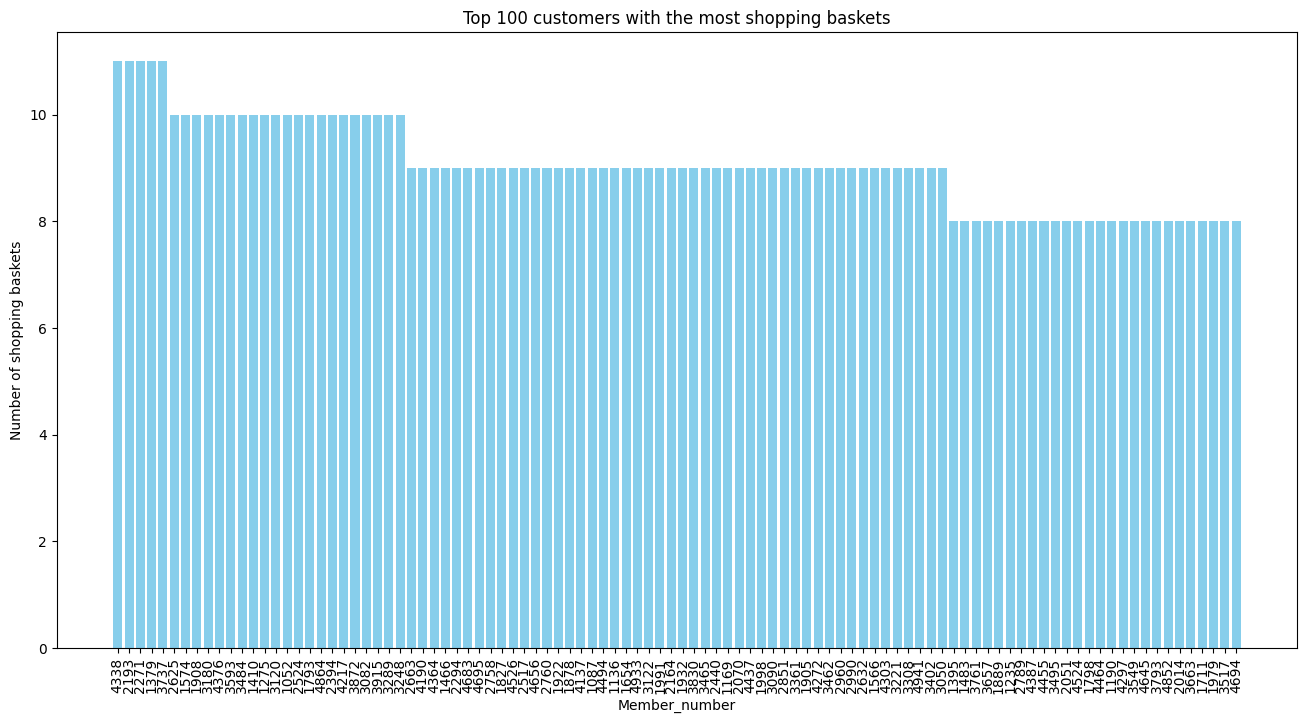

In [ ]:
print("Top 100 customers with the most shopping baskets:\n")
result_f2_df = f2_df(df)

The number of times items have been purchased (in shopping baskets) by month:

+-----+-----+
|month|count|
+-----+-----+
|    1| 3333|
|    2| 3032|
|    3| 3283|
|    4| 3172|
|    5| 3335|
|    6| 3316|
|    7| 3268|
|    8| 3498|
|    9| 2963|
|   10| 3218|
|   11| 3273|
|   12| 3074|
+-----+-----+



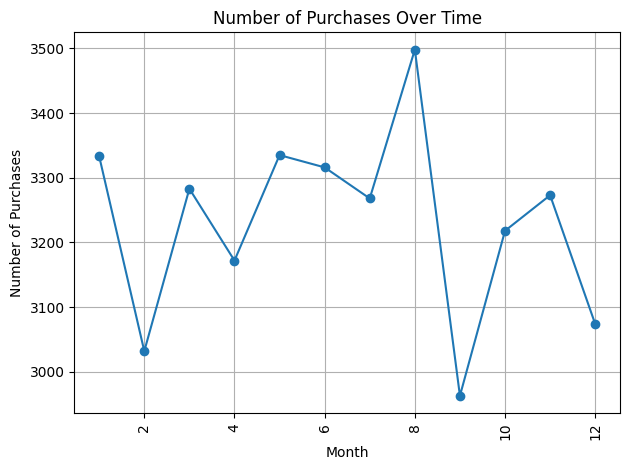

In [ ]:
print("The number of times items have been purchased (in shopping baskets) by month:\n")
result_f3_df = f3_df(df)

The number of purchases (shopping baskets) made by customers each month:

+----+-----+-----+
|year|month|count|
+----+-----+-----+
|2014|1    |659  |
|2014|2    |671  |
|2014|3    |650  |
|2014|4    |657  |
|2014|5    |702  |
|2014|6    |653  |
|2014|7    |700  |
|2014|8    |673  |
|2014|9    |596  |
|2014|10   |694  |
|2014|11   |661  |
|2014|12   |665  |
|2015|1    |632  |
|2015|2    |522  |
|2015|3    |584  |
|2015|4    |567  |
|2015|5    |585  |
|2015|6    |602  |
|2015|7    |572  |
|2015|8    |660  |
|2015|9    |548  |
|2015|10   |566  |
|2015|11   |611  |
|2015|12   |533  |
+----+-----+-----+



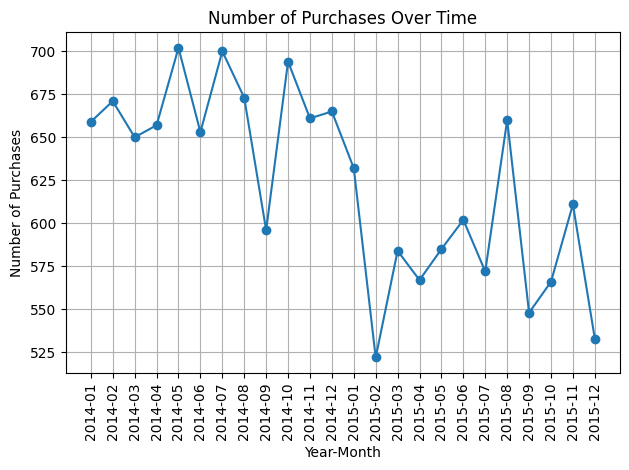

In [ ]:
print("The number of purchases (shopping baskets) made by customers each month:\n")
result_f4_df = f4_df(df)

##**Task 03:**

In [ ]:
from pyspark.sql.types import ArrayType, IntegerType
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.sql import functions as F
import hashlib

def hash_function(item1, item2, num_bucket):
    combined = f"{item1}_{item2}".encode('utf-8')
    hash_object = hashlib.sha256(combined)
    # return (hash(item1) + hash(item2)) % num_bucket
    return int(hash_object.hexdigest(), 16) % num_bucket

def create_bit_vector(count, num_buckets, support_threshold):
    return 1 if count >= support_threshold else 0

class PCY:
    def __init__(self, support_threshold, min_confidence, num_bucket):
        self.support_threshold = support_threshold
        self.min_confidence = min_confidence
        self.num_bucket = num_bucket
        self.list_pair = []

    def discover_baskets(self, df):
        df_baskets = df.select('Member_number', 'Date', 'itemDescription') \
                       .groupBy('Member_number', 'Date') \
                       .agg(F.collect_set('itemDescription').alias('Items')) \
                       .orderBy('Date')
        return df_baskets

    def find_frequent_items(self, df):
        df_frequent_items = df.groupBy('itemDescription') \
                              .count() \
                              .filter(F.col('count') >= self.support_threshold)
        return df_frequent_items

    def filter_baskets(self, df_frequent_items, df_baskets):
        exploded_baskets = df_baskets.withColumn("Item", F.explode("Items"))
        filtered_items = exploded_baskets.join(df_frequent_items, exploded_baskets["Item"] == df_frequent_items["itemDescription"], "inner") \
                                         .select(exploded_baskets["*"])
        result_baskets = filtered_items.groupBy("Member_number", "Date") \
                                       .agg(F.collect_list("Item").alias("Items"))
        return result_baskets

    def create_pair(self, df_baskets):
        df_exploded = df_baskets.withColumn("Item", F.explode(F.col("Items")))
        df_pairs = df_exploded.alias("df1") \
                              .join(df_exploded.alias("df2"),
                                    (F.col("df1.Member_number") == F.col("df2.Member_number")) &
                                    (F.col("df1.Date") == F.col("df2.Date")) &
                                    (F.col("df1.Item") < F.col("df2.Item"))) \
                              .select(F.col("df1.Member_number"), F.col("df1.Date"),
                                      F.array(F.col("df1.Item"), F.col("df2.Item")).alias("Pair"))
        self.list_pair = df_pairs
        df_pairs = df_pairs.select("Pair")
        return df_pairs.distinct()


    def find_bucket_number(self, pairs):
        num_bucket = self.num_bucket
        hash_udf = F.udf(lambda item1, item2:
                         hash_function(item1, item2, num_bucket),
                         returnType=IntegerType()
                         )
        df_unique_pairs_only = pairs.withColumn("bucket_number",
                                                hash_udf(F.col("Pair")[0],
                                                         F.col("Pair")[1])
                                                )
        return df_unique_pairs_only
       # A, B     0
       # B, C     1
       # C, D     1

    def count_bucket(self, bucket_number_list):
        bucket_counts = bucket_number_list.groupBy("bucket_number") \
                                           .agg(
                                               F.count("*").alias("count"),
                                               F.collect_set("Pair").alias("Pairs")
                                           ) \
                                           .orderBy("bucket_number")
        return bucket_counts

      #  0   10     0
      #  1   20    1      S = 15

    def vector_bit(self, bucket_counts): # 0 1
      num_buckets = self.num_bucket
      support_threshold = self.support_threshold

      create_bit_vector_udf = F.udf(
          lambda count: create_bit_vector(count, num_buckets, support_threshold),
          IntegerType()
      )

      df_with_vector = bucket_counts.withColumn("bit_vector", create_bit_vector_udf(F.col("count"))) \
                                    .filter(F.col('bit_vector') == 1)
      return df_with_vector


    def count_frequent_pairs(self, vector_bit):
      df_exploded = vector_bit.select('bucket_number', 'count', 'Pairs', 'bit_vector') \
                              .withColumn("Pair", F.explode(F.col("Pairs")))
      df_exploded = df_exploded.select('Pair')
      count_pair = self.list_pair.groupBy("Pair").count()

      df_with_count = df_exploded.join(count_pair, on="Pair", how="left") \
                                 .filter(F.col('count') >= self.support_threshold)
      return df_with_count


      # A, B  10
      # B, C 20
      # D, A 30



      # A, B
      # D, A


      # a, b 10     A 20
      # B, C NULL
      # D, a 30    d 30

    def calculate_confidence(self, frequent_pairs_df, item_support_df):
      df_with_support_A = frequent_pairs_df \
          .withColumn("Item_A", F.col("Pair").getItem(0)) \
          .join(item_support_df.withColumnRenamed("count", "support_A"),
                F.col("Item_A") == item_support_df["itemDescription"], "inner")

      df_with_support_A = df_with_support_A.select("Pair", "support_A", "count")

      # Tính độ tin cậy: support(A -> B) = support(A, B) / support(A)
      df_with_confidence = df_with_support_A \
          .withColumn("confidence", F.col("count") / F.col("support_A"))\
          .filter(F.col('confidence') >= self.min_confidence)
      return df_with_confidence.select("Pair", "Confidence")

    def run(self, df):
      df_baskets = self.discover_baskets(df)
      df_baskets.show(truncate=False)
      df_frequent_items = self.find_frequent_items(df)
      df_frequent_items.show(truncate=False)
      df_filter_baskets = self.filter_baskets(df_frequent_items, df_baskets)
      df_filter_baskets.show(truncate=False)
      pairs = self.create_pair(df_filter_baskets)
      pairs.show(truncate=False)
      find_bucket_number = self.find_bucket_number(pairs)
      find_bucket_number.show(truncate=False)
      count_bucket = self.count_bucket(find_bucket_number)
      count_bucket.show(truncate=False)
      vector_bit = self.vector_bit(count_bucket)
      vector_bit.show(truncate=False)
      count_frequent_pairs = self.count_frequent_pairs(vector_bit)
      count_frequent_pairs.show(truncate=False)
      calculate_confidence = self.calculate_confidence(count_frequent_pairs, df_frequent_items)
      return calculate_confidence, count_frequent_pairs

pcy = PCY(support_threshold=2, min_confidence=.005, num_bucket=5000)
result, count_frequent_pairs = pcy.run(df)
count_frequent_pairs.show(truncate=False)
result.show(truncate=False)



+---------------------------------------+-----+
|Pair                                   |count|
+---------------------------------------+-----+
|[cocoa drinks, whole milk]             |2    |
|[cream cheese , white wine]            |2    |
|[hard cheese, pip fruit]               |16   |
|[jam, whole milk]                      |5    |
|[meat, other vegetables]               |32   |
|[other vegetables, specialty cheese]   |4    |
|[pastry, soda]                         |61   |
|[Instant food products, sausage]       |2    |
|[UHT-milk, onions]                     |5    |
|[baking powder, hamburger meat]        |2    |
|[candy, whipped/sour cream]            |8    |
|[chicken, processed cheese]            |3    |
|[domestic eggs, fruit/vegetable juice] |16   |
|[frankfurter, hamburger meat]          |10   |
|[ham, ice cream]                       |2    |
|[margarine, seasonal products]         |3    |
|[packaged fruit/vegetables, whole milk]|8    |
|[soda, tropical fruit]                 

In [ ]:
from pyspark.sql.functions import concat_ws
! rm -rf output.csv
df_converted = result.withColumn("Pair", concat_ws(", ", "Pair"))

df_converted.coalesce(1).write.csv('output.csv', header=True, mode="overwrite")


##**Task 04:**

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.sql import functions as F
class A_Priori:
    def __init__(self, support_threshold, min_confidence):
        self.support_threshold = support_threshold
        self.min_confidence = min_confidence

    def discover_baskets(self, df):
        df_baskets = df.select('Member_number', 'Date', 'itemDescription') \
                       .groupBy('Member_number', 'Date') \
                       .agg(F.collect_set('itemDescription').alias('Items')) \
                       .orderBy('Date')
        return df_baskets

    def find_frequent_items(self, df):
        df_frequent_items = df.groupBy('itemDescription') \
                              .count() \
                              .filter(F.col('count') >= self.support_threshold)
        return df_frequent_items

    def creare_pair_basket(self, df_frequent_items, df_baskets):
        exploded_baskets = df_baskets.withColumn("Item", F.explode("Items"))
        filtered_items = exploded_baskets.join(df_frequent_items, exploded_baskets["Item"] == df_frequent_items["itemDescription"], "inner") \
                                         .select(exploded_baskets["*"])
        result_baskets = filtered_items.groupBy("Member_number", "Date") \
                                       .agg(F.collect_list("Item").alias("Items"))

        df_exploded = result_baskets.withColumn("Item", F.explode(F.col("Items")))
        df_pairs = df_exploded.alias("df1") \
                              .join(df_exploded.alias("df2"),
                                    (F.col("df1.Member_number") == F.col("df2.Member_number")) &
                                    (F.col("df1.Date") == F.col("df2.Date")) &
                                    (F.col("df1.Item") < F.col("df2.Item"))) \
                              .select(F.col("df1.Member_number"), F.col("df1.Date"),
                                      F.array(F.col("df1.Item"), F.col("df2.Item")).alias("Pairs"))
        df_pairs = df_pairs.select("Pairs")
        return df_pairs

    def find_frequent_pairs(self, df_baskets, df_frequent_items):
        pairs = df_frequent_items.alias("df1") \
                                .join(df_frequent_items.alias("df2"),
                                      F.col("df1.itemDescription") < F.col("df2.itemDescription")) \
                                .select(F.array("df1.itemDescription", "df2.itemDescription").alias("Pairs"),
                                        "df1.count", "df2.count") \
                                .select("Pairs")

        count_pair = df_baskets.groupBy("Pairs").count()
        df_with_count = pairs.join(count_pair, on="Pairs", how="left") \
                                 .filter(F.col('count') >= self.support_threshold)
        return df_with_count

    def calculate_confidence(self, frequent_pairs_df, item_support_df):
      df_with_support_A = frequent_pairs_df \
          .withColumn("Item_A", F.col("Pairs").getItem(0)) \
          .join(item_support_df.withColumnRenamed("count", "support_A"),
                F.col("Item_A") == item_support_df["itemDescription"], "inner")

      df_with_support_A = df_with_support_A.select("Pairs", "support_A", "count")

      # Tính độ tin cậy: support(A -> B) = support(A, B) / support(A)
      df_with_confidence = df_with_support_A \
          .withColumn("confidence", F.col("count") / F.col("support_A"))\
          .filter(F.col('confidence') >= self.min_confidence)
      return df_with_confidence.select("Pairs", "Confidence")

    def run(self, df):
        df_baskets = self.discover_baskets(df)
        df_frequent_items = self.find_frequent_items(df)
        creare_pair_basket = self.creare_pair_basket(df_frequent_items, df_baskets)
        df_frequent_pairs = self.find_frequent_pairs(creare_pair_basket, df_frequent_items)
        calculate_confidence = self.calculate_confidence(df_frequent_pairs, df_frequent_items)
        # creare_pair_basket.show(truncate=False)
        # df_frequent_items.show(truncate=False)
        # df_frequent_pairs.show(100,truncate=False)  # Display frequent item pairs
        # calculate_confidence.show(100,truncate=False)  # Display frequent item pairs
        return None

apriori = A_Priori(support_threshold=2, min_confidence=0.005)
apriori.run(df)

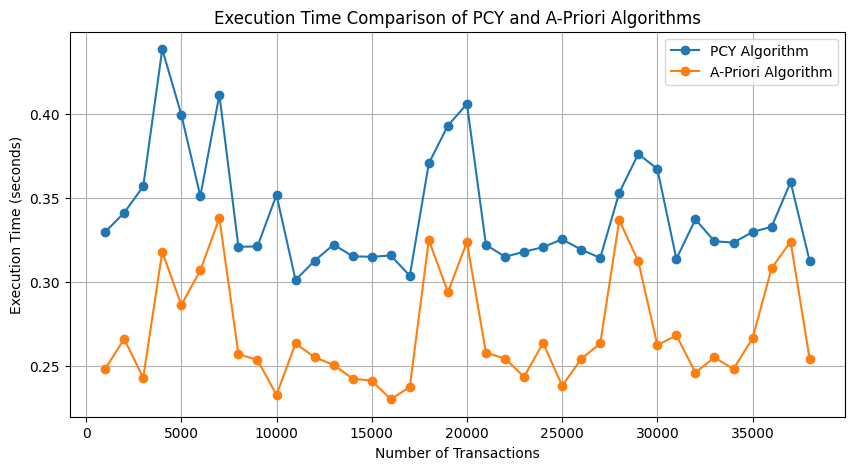

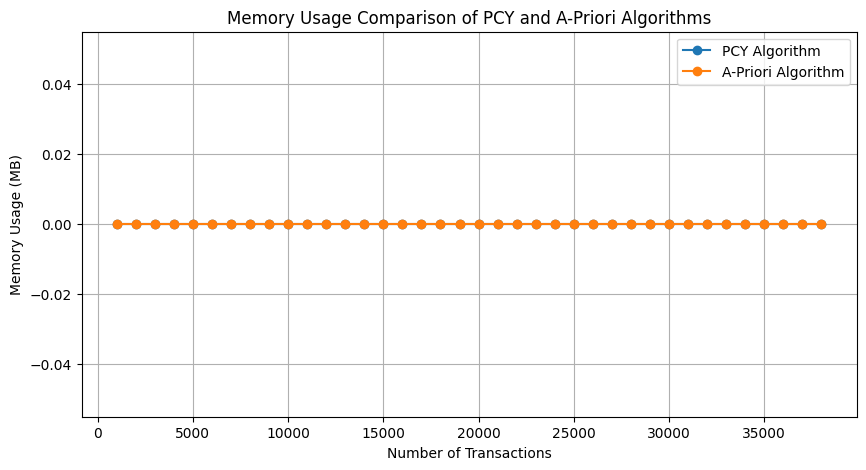

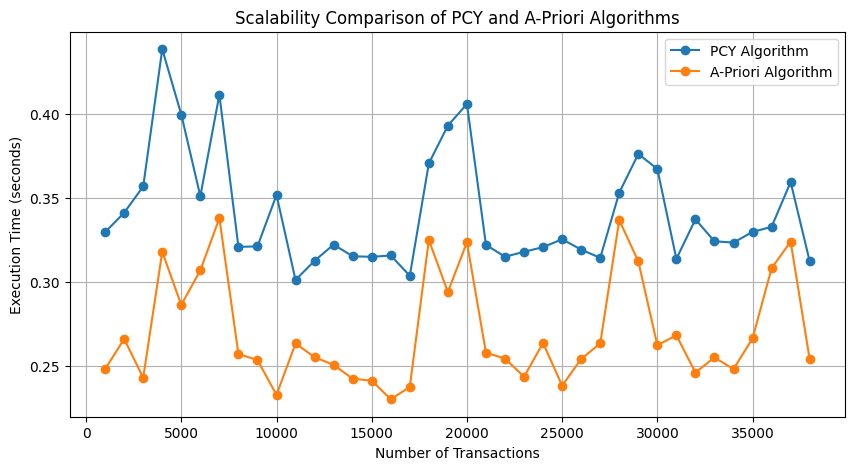

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import random
import time
import matplotlib.pyplot as plt
import psutil

spark = SparkSession.builder.appName("Comparison").getOrCreate()

def generate_sample_data(num_transactions, num_items):
    data = []
    for _ in range(num_transactions):
        transaction = random.sample(range(1, num_items + 1), random.randint(1, num_items))
        data.append(transaction)
    return data

def run_comparison(spark):
    pcy_times, apriori_times = [], []
    pcy_memory_usage, apriori_memory_usage = [], []
    sizes = []
    max_size = df.count()

    for size in range(1000, max_size + 1, 1000):
        sizes.append(size)

        sample_data = generate_sample_data(size, 100)

        pcy_start = time.time()
        pcy_memory_before = psutil.Process().memory_info().rss
        pcy = PCY(support_threshold=2, min_confidence=0.005, num_bucket=5000)
        pcy.run(df)
        pcy_memory_after = psutil.Process().memory_info().rss
        pcy_end = time.time()

        pcy_times.append(pcy_end - pcy_start)
        pcy_memory_usage.append((pcy_memory_after - pcy_memory_before) / (1024 * 1024))

        apriori_start = time.time()
        apriori_memory_before = psutil.Process().memory_info().rss
        apriori = A_Priori(support_threshold=2, min_confidence=0.005)
        apriori.run(df)
        apriori_memory_after = psutil.Process().memory_info().rss
        apriori_end = time.time()

        apriori_times.append(apriori_end - apriori_start)
        apriori_memory_usage.append((apriori_memory_after - apriori_memory_before) / (1024 * 1024))  # Convert to MB

    return sizes, pcy_times, apriori_times, pcy_memory_usage, apriori_memory_usagelo

sizes, pcy_times, apriori_times, pcy_memory_usage, apriori_memory_usage = run_comparison(spark)

plt.figure(figsize=(10, 5))
plt.plot(sizes, pcy_times, label='PCY Algorithm', marker='o')
plt.plot(sizes, apriori_times, label='A-Priori Algorithm', marker='o')
plt.xlabel('Number of Transactions')
plt.ylabel('Execution Time (seconds)')
plt.title('Execution Time Comparison of PCY and A-Priori Algorithms')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(sizes, pcy_memory_usage, label='PCY Algorithm', marker='o')
plt.plot(sizes, apriori_memory_usage, label='A-Priori Algorithm', marker='o')
plt.xlabel('Number of Transactions')
plt.ylabel('Memory Usage (MB)')
plt.title('Memory Usage Comparison of PCY and A-Priori Algorithms')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(sizes, pcy_times, label='PCY Algorithm', marker='o')
plt.plot(sizes, apriori_times, label='A-Priori Algorithm', marker='o')
plt.xlabel('Number of Transactions')
plt.ylabel('Execution Time (seconds)')
plt.title('Scalability Comparison of PCY and A-Priori Algorithms')
plt.legend()
plt.grid()
plt.show()



In [ ]:
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.svm import SVC
import matplotlib.pyplot as plt

# Load Wine dataset
wine = datasets.load_wine()
data = pd.DataFrame(wine.data, columns=wine.feature_names)
data['Class'] = wine.target

# Select two features: Alcohol and Malic Acid
X = data[['alcohol', 'malic_acid']].values[10]
y = data['Class'].values[10]

# Filter data for binary classification (Class 0 and Class 1)
binary_mask = (y == 0) | (y == 1)
X = X[binary_mask]
y = y[binary_mask]

# Fit SVM model with Polynomial kernel
svm = SVC(kernel='poly', C=1, degree=3, gamma='scale')  # Change kernel to poly and set degree
svm.fit(X, y)

# Set larger figure size
plt.figure(figsize=(10, 6))

# Plot data points
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=30, edgecolors='k')

# Create grid for decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))

# Predict over grid points
Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.contourf(xx, yy, Z, alpha=0.8, cmap='viridis')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=30, edgecolors='k')

# Labels and legend
plt.xlabel('Alcohol')
plt.ylabel('Malic Acid')
plt.title('SVM Decision Boundary with Polynomial Kernel (degree=3)')
plt.show()
